# Compare normprod outputs from stac and files

Goal:
* Create a subset geometry to use for comparing the output
* Load processed files and clip area to subset geometry

In [3]:
from odc.geo import BoundingBox, GeoBox
import odc.geo.xr
import rioxarray
import pathlib

In [4]:
#### 2. Prydz Bay (EPSG:4326)
AOI_BBOX = BoundingBox(
    left=74.2,
    bottom=-69.5,
    right=75.0,
    top=-69.1,
    crs="EPSG:4326",
)

epsg4326_geom = GeoBox.from_bbox(AOI_BBOX, resolution=0.001)
espg3031_geom = epsg4326_geom.to_crs("EPSG:3031")

In [5]:
### Set file to compare
file = pathlib.Path("./DATA/created_on_aws/S1_image_pair_20210708T145617_20210720T145618/normprod_smovar_window11.tif")

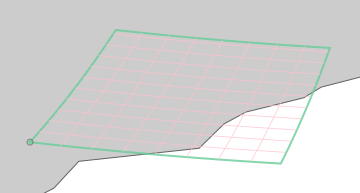

In [6]:
# Load and clip file-based output

# Open into an xarray.DataArray
raster = rioxarray.open_rasterio(file).squeeze("band", drop=True)

raster.odc.geobox

In [7]:
raster.odc.geobox.resolution

Resolution(x=40, y=-40)

In [8]:
raster.odc.geobox.boundingbox

BoundingBox(left=2168720.0, bottom=374040.0, right=2582920.0, top=690840.0, crs=CRS('PROJCS["WGS 84 / Antarctic Polar Stereographic",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Polar_Stereographic"],PARAMETER["latitude_of_origin",-71],PARAMETER["central_meridian",0],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",NORTH],AXIS["Northing",NORTH],AUTHORITY["EPSG","3031"]]'))

In [9]:
raster_cropped = raster.odc.crop(epsg4326_geom.geographic_extent)

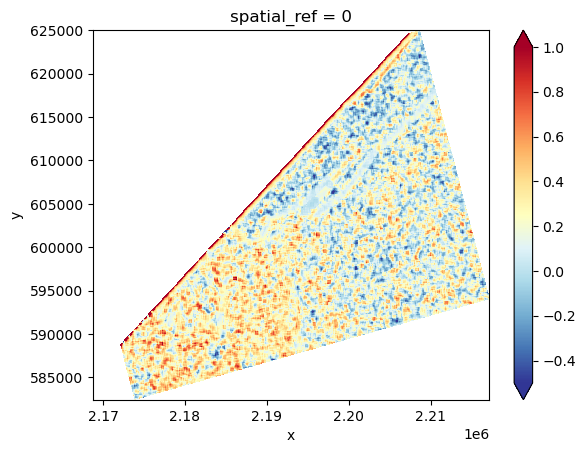

In [10]:
raster_cropped.plot.imshow(cmap="RdYlBu_r", vmin=-0.5, vmax=1)